In [4]:
# Data Loading

In [5]:
import pandas as pd

column_names = ['user_id', 'movie_id', 'rating', 'timestamp']
df = pd.read_csv('u.data', sep='\t', names=column_names)
print(df.head())

   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596


In [6]:
df.shape

(100000, 4)

In [7]:
df.isnull().sum()

user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

In [8]:
max = df['rating'].max()
min = df['rating'].min()

In [9]:
max

np.int64(5)

In [10]:
min

np.int64(1)

In [11]:
df['user_id'].unique().size

943

In [12]:
df['movie_id'].unique().size

1682

In [13]:
unique_users = df['user_id'].unique()

In [14]:
for idx, user_id in enumerate(unique_users):
    print(idx, user_id)

0 196
1 186
2 22
3 244
4 166
5 298
6 115
7 253
8 305
9 6
10 62
11 286
12 200
13 210
14 224
15 303
16 122
17 194
18 291
19 234
20 119
21 167
22 299
23 308
24 95
25 38
26 102
27 63
28 160
29 50
30 301
31 225
32 290
33 97
34 157
35 181
36 278
37 276
38 7
39 10
40 284
41 201
42 287
43 246
44 242
45 249
46 99
47 178
48 251
49 81
50 260
51 25
52 59
53 72
54 87
55 42
56 292
57 20
58 13
59 138
60 60
61 57
62 223
63 189
64 243
65 92
66 241
67 254
68 293
69 127
70 222
71 267
72 11
73 8
74 162
75 279
76 145
77 28
78 135
79 32
80 90
81 216
82 250
83 271
84 265
85 198
86 168
87 110
88 58
89 237
90 94
91 128
92 44
93 264
94 41
95 82
96 262
97 174
98 43
99 84
100 269
101 259
102 85
103 213
104 121
105 49
106 155
107 68
108 172
109 19
110 268
111 5
112 80
113 66
114 18
115 26
116 130
117 256
118 1
119 56
120 15
121 207
122 232
123 52
124 161
125 148
126 125
127 83
128 272
129 151
130 54
131 16
132 91
133 294
134 229
135 36
136 70
137 14
138 295
139 233
140 214
141 192
142 100
143 307
144 297
145 193
1

In [15]:
user_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(unique_users)
}

In [16]:
unique_movies = df['movie_id'].unique()

In [17]:
movie_to_idx = {
    movie_id: idx
    for idx, movie_id in enumerate(unique_movies)
}

In [18]:
df = df.drop(columns = 'timestamp' )

In [19]:
df

,user_id,movie_id,rating
0,196,242,3
1,186,302,3
2,22,377,1
3,244,51,2
4,166,346,1
...,...,...,...
99995,880,476,3
99996,716,204,5
99997,276,1090,1
99998,13,225,2


In [20]:
df['user_idx'] = df['user_id'].map(user_to_idx)
df['movie_idx'] = df['movie_id'].map(movie_to_idx)

In [21]:
df

,user_id,movie_id,rating,user_idx,movie_idx
0,196,242,3,0,0
1,186,302,3,1,1
2,22,377,1,2,2
3,244,51,2,3,3
4,166,346,1,4,4
...,...,...,...,...,...
99995,880,476,3,875,173
99996,716,204,5,708,247
99997,276,1090,1,37,1004
99998,13,225,2,58,443


In [22]:
data = df.drop(columns=['user_id', 'movie_id'])

In [23]:
data

,rating,user_idx,movie_idx
0,3,0,0
1,3,1,1
2,1,2,2
3,2,3,3
4,1,4,4
...,...,...,...
99995,3,875,173
99996,5,708,247
99997,1,37,1004
99998,2,58,443


In [94]:
for i, item in enumerate(data.iterrows()):
    if i >= 10:  
        break
    print(item)

(0, rating       3
user_idx     0
movie_idx    0
Name: 0, dtype: int64)
(1, rating       3
user_idx     1
movie_idx    1
Name: 1, dtype: int64)
(2, rating       1
user_idx     2
movie_idx    2
Name: 2, dtype: int64)
(3, rating       2
user_idx     3
movie_idx    3
Name: 3, dtype: int64)
(4, rating       1
user_idx     4
movie_idx    4
Name: 4, dtype: int64)
(5, rating       4
user_idx     5
movie_idx    5
Name: 5, dtype: int64)
(6, rating       2
user_idx     6
movie_idx    6
Name: 6, dtype: int64)
(7, rating       5
user_idx     7
movie_idx    7
Name: 7, dtype: int64)
(8, rating       3
user_idx     8
movie_idx    8
Name: 8, dtype: int64)
(9, rating       3
user_idx     9
movie_idx    9
Name: 9, dtype: int64)


# Train test split

In [95]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size = 0.2, random_state = 42)

In [96]:
print(train_df)

       rating  user_idx  movie_idx
75220       1       804        901
48955       5       467        488
44966       4       465        139
13568       4       321        289
92727       4       618        261
...       ...       ...        ...
6265        2        81        146
54886       5       339        695
76820       3       434        355
860         3        40         51
15795       3        70        113

[80000 rows x 3 columns]


In [97]:
n_users = data['user_idx'].nunique()
n_movies = data['movie_idx'].nunique()

In [98]:
k = 20

In [99]:
import numpy as np

P = np.random.normal(   
    0, 
    0.1, 
    (n_users, k)
)

Q = np.random.normal(
    0,
    0.1,
    (n_movies, k)
)

In [100]:
P

array([[-0.03685184, -0.08007081, -0.16900662, ..., -0.05598682,
         0.0787192 , -0.07106696],
       [-0.05836234, -0.091169  ,  0.0547766 , ..., -0.01728742,
        -0.11368339, -0.0540946 ],
       [-0.02451053,  0.06379879,  0.05706121, ...,  0.05695067,
         0.10918042, -0.13676604],
       ...,
       [ 0.10186695,  0.08118383, -0.03251148, ...,  0.00276886,
         0.03753894,  0.17063963],
       [-0.10620641, -0.02746939,  0.12974612, ..., -0.07529583,
        -0.00662165, -0.06126965],
       [ 0.10836327,  0.14967303,  0.08127801, ..., -0.05909108,
         0.1036329 , -0.10728726]], shape=(943, 20))

In [101]:
Q

array([[-0.04971454,  0.06761212, -0.06325154, ...,  0.0821479 ,
         0.13893327,  0.16574737],
       [-0.01816475, -0.09554068,  0.00537729, ..., -0.03631551,
        -0.02030975,  0.0641723 ],
       [ 0.09735238, -0.00480593,  0.03153275, ..., -0.07096797,
         0.0732412 ,  0.08788896],
       ...,
       [ 0.05964815, -0.06009032, -0.08748017, ...,  0.05555027,
         0.23211765,  0.06682044],
       [-0.01511129, -0.01645821, -0.02905899, ...,  0.1027968 ,
        -0.07035669, -0.08230428],
       [-0.02515455,  0.04802671, -0.1063467 , ...,  0.00325412,
        -0.02860582, -0.04413844]], shape=(1682, 20))

# Loop (Epochs)

In [102]:
train_df

,rating,user_idx,movie_idx
75220,1,804,901
48955,5,467,488
44966,4,465,139
13568,4,321,289
92727,4,618,261
...,...,...,...
6265,2,81,146
54886,5,339,695
76820,3,434,355
860,3,40,51


In [103]:
print(P)

[[-0.03685184 -0.08007081 -0.16900662 ... -0.05598682  0.0787192
  -0.07106696]
 [-0.05836234 -0.091169    0.0547766  ... -0.01728742 -0.11368339
  -0.0540946 ]
 [-0.02451053  0.06379879  0.05706121 ...  0.05695067  0.10918042
  -0.13676604]
 ...
 [ 0.10186695  0.08118383 -0.03251148 ...  0.00276886  0.03753894
   0.17063963]
 [-0.10620641 -0.02746939  0.12974612 ... -0.07529583 -0.00662165
  -0.06126965]
 [ 0.10836327  0.14967303  0.08127801 ... -0.05909108  0.1036329
  -0.10728726]]


In [104]:
pred = np.dot(
    P[u],
    Q[i]
)

# Error

In [105]:
error = r - pred

In [106]:
print(error)

5.044802698609161


# Update P & Q

In [107]:
lr = 0.01

In [108]:
P[u] += lr * error * Q[i]

Q[i] += lr * error * P[u]

# Train

In [109]:
# With k = 20 and epoch = 40 and lr = 0.01

epochs = 15

for epoch in range(epochs):

    # -------- Train --------
    total_error = 0

    for _, row in train_df.iterrows():

        u = int(row['user_idx'])
        i = int(row['movie_idx'])
        r = row['rating']

        pred = np.dot(P[u], Q[i])
        error = r - pred

        p_u = P[u].copy()
        q_i = Q[i].copy()

        P[u] += lr * (error * q_i - lambda_reg * p_u)
        Q[i] += lr * (error * p_u - lambda_reg * q_i)

        total_error += error**2

    train_rmse = np.sqrt(total_error / len(train_df))

    # -------- Test --------
    predictions = []
    actuals = []

    for _, row in test_df.iterrows():

        u = int(row['user_idx'])
        i = int(row['movie_idx'])
        r = row['rating']

        pred = np.dot(P[u], Q[i])

        predictions.append(pred)
        actuals.append(r)

    test_rmse = np.sqrt(
        np.mean((np.array(actuals) - np.array(predictions))**2)
    )

    print(f"Epoch {epoch+1}: Train={train_rmse:.4f}, Test={test_rmse:.4f}")

Epoch 1: Train=3.5608, Test=2.6808
Epoch 2: Train=1.7489, Test=1.2717
Epoch 3: Train=1.1294, Test=1.0749
Epoch 4: Train=1.0111, Test=1.0176
Epoch 5: Train=0.9655, Test=0.9927
Epoch 6: Train=0.9384, Test=0.9783
Epoch 7: Train=0.9174, Test=0.9685
Epoch 8: Train=0.8990, Test=0.9614
Epoch 9: Train=0.8819, Test=0.9562
Epoch 10: Train=0.8655, Test=0.9523
Epoch 11: Train=0.8494, Test=0.9496
Epoch 12: Train=0.8336, Test=0.9478
Epoch 13: Train=0.8181, Test=0.9470
Epoch 14: Train=0.8031, Test=0.9470
Epoch 15: Train=0.7887, Test=0.9477


In [73]:
# With k = 15 and epoch = 40 and lr = 0.01

epochs = 40

for epoch in range(epochs):

    # -------- Train --------
    total_error = 0

    for _, row in train_df.iterrows():

        u = int(row['user_idx'])
        i = int(row['movie_idx'])
        r = row['rating']

        pred = np.dot(P[u], Q[i])
        error = r - pred

        p_u = P[u].copy()
        q_i = Q[i].copy()

        P[u] += lr * (error * q_i - lambda_reg * p_u)
        Q[i] += lr * (error * p_u - lambda_reg * q_i)

        total_error += error**2

    train_rmse = np.sqrt(total_error / len(train_df))

    # -------- Test --------
    predictions = []
    actuals = []

    for _, row in test_df.iterrows():

        u = int(row['user_idx'])
        i = int(row['movie_idx'])
        r = row['rating']

        pred = np.dot(P[u], Q[i])

        predictions.append(pred)
        actuals.append(r)

    test_rmse = np.sqrt(
        np.mean((np.array(actuals) - np.array(predictions))**2)
    )

    print(f"Epoch {epoch+1}: Train={train_rmse:.4f}, Test={test_rmse:.4f}")

Epoch 1: Train=3.5376, Test=2.5896
Epoch 2: Train=1.7187, Test=1.2671
Epoch 3: Train=1.1308, Test=1.0748
Epoch 4: Train=1.0152, Test=1.0182
Epoch 5: Train=0.9709, Test=0.9937
Epoch 6: Train=0.9453, Test=0.9796
Epoch 7: Train=0.9258, Test=0.9699
Epoch 8: Train=0.9086, Test=0.9628
Epoch 9: Train=0.8927, Test=0.9576
Epoch 10: Train=0.8776, Test=0.9538
Epoch 11: Train=0.8632, Test=0.9512
Epoch 12: Train=0.8494, Test=0.9496
Epoch 13: Train=0.8361, Test=0.9488
Epoch 14: Train=0.8233, Test=0.9488
Epoch 15: Train=0.8112, Test=0.9494
Epoch 16: Train=0.7998, Test=0.9505
Epoch 17: Train=0.7891, Test=0.9520
Epoch 18: Train=0.7791, Test=0.9538
Epoch 19: Train=0.7699, Test=0.9557
Epoch 20: Train=0.7614, Test=0.9578
Epoch 21: Train=0.7535, Test=0.9600
Epoch 22: Train=0.7463, Test=0.9622
Epoch 23: Train=0.7396, Test=0.9643
Epoch 24: Train=0.7335, Test=0.9665
Epoch 25: Train=0.7278, Test=0.9686
Epoch 26: Train=0.7226, Test=0.9706
Epoch 27: Train=0.7177, Test=0.9726
Epoch 28: Train=0.7132, Test=0.9746
E

# Test

In [110]:
predictions = []
actuals = []

for _, row in test_df.iterrows():

    u = int(row['user_idx'])
    i = int(row['movie_idx'])
    r = row['rating']

    pred = np.dot(P[u], Q[i])

    predictions.append(pred)
    actuals.append(r)

rmse = np.sqrt(
    np.mean(
        (np.array(actuals) - np.array(predictions))**2
    )
)

print("Test RMSE:", rmse)

Test RMSE: 0.9477147673271413


In [111]:
lambda_reg = 0.02

P[u] += lr * (error * q_i - lambda_reg * p_u)
Q[i] += lr * (error * p_u - lambda_reg * q_i)

In [112]:
predictions = []
actuals = []

for _, row in test_df.iterrows():

    u = int(row['user_idx'])
    i = int(row['movie_idx'])
    r = row['rating']

    pred = np.dot(P[u], Q[i])

    predictions.append(pred)
    actuals.append(r)

rmse = np.sqrt(
    np.mean(
        (np.array(actuals) - np.array(predictions))**2
    )
)

print("Test RMSE:", rmse)

Test RMSE: 0.9477168590197552


# Load movie info dataset

In [113]:
"""u.item     -- Information about the items (movies); this is a tab separated
              list of
              movie id | movie title | release date | video release date |
              IMDb URL | unknown | Action | Adventure | Animation |
              Children's | Comedy | Crime | Documentary | Drama | Fantasy |
              Film-Noir | Horror | Musical | Mystery | Romance | Sci-Fi |
              Thriller | War | Western |
              The last 19 fields are the genres, a 1 indicates the movie
              is of that genre, a 0 indicates it is not; movies can be in
              several genres at once.
              The movie ids are the ones used in the u.data data set."""

columns = [
    'movie_id', 'movie_title', 'release_date', 'video_release_date',
    'IMDb URL', 'unknown', 'Action', 'Adventure', 'Animation',
    "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
    'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
    'Thriller', 'War', 'Western'
]

info = pd.read_csv('u.item', sep='|', names=columns, encoding='latin-1')
info

,movie_id,movie_title,release_date,video_release_date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1678,1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1679,1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1680,1681,You So Crazy (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Mapping

In [114]:
df

,user_id,movie_id,rating,user_idx,movie_idx
0,196,242,3,0,0
1,186,302,3,1,1
2,22,377,1,2,2
3,244,51,2,3,3
4,166,346,1,4,4
...,...,...,...,...,...
99995,880,476,3,875,173
99996,716,204,5,708,247
99997,276,1090,1,37,1004
99998,13,225,2,58,443


In [115]:
mapping = info.set_index('movie_id')['movie_title']

In [116]:
cols = ['user_id','movie_id','rating', 'user_idx']
new_df = df[cols]
new_df

,user_id,movie_id,rating,user_idx
0,196,242,3,0
1,186,302,3,1
2,22,377,1,2
3,244,51,2,3
4,166,346,1,4
...,...,...,...,...
99995,880,476,3,875
99996,716,204,5,708
99997,276,1090,1,37
99998,13,225,2,58


In [117]:
new_df['movie_title'] = new_df['movie_id'].map(mapping)
new_df

,user_id,movie_id,rating,user_idx,movie_title
0,196,242,3,0,Kolya (1996)
1,186,302,3,1,L.A. Confidential (1997)
2,22,377,1,2,Heavyweights (1994)
3,244,51,2,3,Legends of the Fall (1994)
4,166,346,1,4,Jackie Brown (1997)
...,...,...,...,...,...
99995,880,476,3,875,"First Wives Club, The (1996)"
99996,716,204,5,708,Back to the Future (1985)
99997,276,1090,1,37,Sliver (1993)
99998,13,225,2,58,101 Dalmatians (1996)


In [118]:
info[info['movie_id'] == 302]

,movie_id,movie_title,release_date,video_release_date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
301,302,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0


In [119]:
zero_movies = test_df[test_df['movie_idx'] == 0]
print("Rows with movie_idx = 0:")
print(zero_movies)

print(f"\nNumber of rows with movie_idx = 0: {len(zero_movies)}")

Rows with movie_idx = 0:
       rating  user_idx  movie_idx
92283       4       732          0
5548        4       290          0
40255       4       620          0
56709       4       230          0
37300       4       631          0
95720       5         8          0
77669       4       691          0
79462       3       752          0
253         3        27          0
24012       5       229          0
12734       4       352          0
51379       5       184          0
45756       4       121          0
8063        5       259          0
82960       1       719          0
20352       4       354          0
16803       4       189          0
29110       5       304          0
85671       5       866          0
33815       5       558          0
67683       3       872          0
60498       5       699          0

Number of rows with movie_idx = 0: 22


In [120]:
zero_movies = train_df[train_df['movie_idx'] == 0]
print("Rows with movie_idx = 0:")
print(zero_movies)

print(f"\nNumber of rows with movie_idx = 0: {len(zero_movies)}")

Rows with movie_idx = 0:
       rating  user_idx  movie_idx
77320       4       530          0
99759       3       713          0
53764       4       735          0
629         5       218          0
37093       1        35          0
...       ...       ...        ...
20538       5       280          0
72274       5       114          0
51991       5       788          0
10729       2       146          0
60263       3       472          0

[95 rows x 3 columns]

Number of rows with movie_idx = 0: 95


In [121]:
print(test_df['movie_idx'].max())

1681


In [122]:
new_df

,user_id,movie_id,rating,user_idx,movie_title
0,196,242,3,0,Kolya (1996)
1,186,302,3,1,L.A. Confidential (1997)
2,22,377,1,2,Heavyweights (1994)
3,244,51,2,3,Legends of the Fall (1994)
4,166,346,1,4,Jackie Brown (1997)
...,...,...,...,...,...
99995,880,476,3,875,"First Wives Club, The (1996)"
99996,716,204,5,708,Back to the Future (1985)
99997,276,1090,1,37,Sliver (1993)
99998,13,225,2,58,101 Dalmatians (1996)


In [123]:
df['movie_name'] = df['movie_id'].map(mapping)
df

,user_id,movie_id,rating,user_idx,movie_idx,movie_name
0,196,242,3,0,0,Kolya (1996)
1,186,302,3,1,1,L.A. Confidential (1997)
2,22,377,1,2,2,Heavyweights (1994)
3,244,51,2,3,3,Legends of the Fall (1994)
4,166,346,1,4,4,Jackie Brown (1997)
...,...,...,...,...,...,...
99995,880,476,3,875,173,"First Wives Club, The (1996)"
99996,716,204,5,708,247,Back to the Future (1985)
99997,276,1090,1,37,1004,Sliver (1993)
99998,13,225,2,58,443,101 Dalmatians (1996)


In [124]:
# Create the rating matrix (users as rows, movies as columns)
rating_matrix = df.pivot(index='user_idx', 
                         columns='movie_idx', 
                         values='rating')
rating_matrix

movie_idx,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
user_idx,,,,,,,,,,,,,,,,,,,,,
0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,1.0,NaN,NaN,NaN,3.0,NaN,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,NaN,NaN,4.0,NaN,4.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
939,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [125]:
new_df

,user_id,movie_id,rating,user_idx,movie_title
0,196,242,3,0,Kolya (1996)
1,186,302,3,1,L.A. Confidential (1997)
2,22,377,1,2,Heavyweights (1994)
3,244,51,2,3,Legends of the Fall (1994)
4,166,346,1,4,Jackie Brown (1997)
...,...,...,...,...,...
99995,880,476,3,875,"First Wives Club, The (1996)"
99996,716,204,5,708,Back to the Future (1985)
99997,276,1090,1,37,Sliver (1993)
99998,13,225,2,58,101 Dalmatians (1996)


In [126]:
new_df[new_df['movie_title'].str.contains('Iron man')]

,user_id,movie_id,rating,user_idx,movie_title


# Clean movie title

In [127]:
new_df

,user_id,movie_id,rating,user_idx,movie_title
0,196,242,3,0,Kolya (1996)
1,186,302,3,1,L.A. Confidential (1997)
2,22,377,1,2,Heavyweights (1994)
3,244,51,2,3,Legends of the Fall (1994)
4,166,346,1,4,Jackie Brown (1997)
...,...,...,...,...,...
99995,880,476,3,875,"First Wives Club, The (1996)"
99996,716,204,5,708,Back to the Future (1985)
99997,276,1090,1,37,Sliver (1993)
99998,13,225,2,58,101 Dalmatians (1996)


In [128]:

new_df['year'] = new_df['movie_title'].str.extract(r'\((\d{4})\)')
new_df['clean_title'] = new_df['movie_title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)

print(new_df[['movie_title', 'clean_title', 'year']].head())

                  movie_title          clean_title  year
0                Kolya (1996)                Kolya  1996
1    L.A. Confidential (1997)    L.A. Confidential  1997
2         Heavyweights (1994)         Heavyweights  1994
3  Legends of the Fall (1994)  Legends of the Fall  1994
4         Jackie Brown (1997)         Jackie Brown  1997


In [129]:
new_df

,user_id,movie_id,rating,user_idx,movie_title,year,clean_title
0,196,242,3,0,Kolya (1996),1996,Kolya
1,186,302,3,1,L.A. Confidential (1997),1997,L.A. Confidential
2,22,377,1,2,Heavyweights (1994),1994,Heavyweights
3,244,51,2,3,Legends of the Fall (1994),1994,Legends of the Fall
4,166,346,1,4,Jackie Brown (1997),1997,Jackie Brown
...,...,...,...,...,...,...,...
99995,880,476,3,875,"First Wives Club, The (1996)",1996,"First Wives Club, The"
99996,716,204,5,708,Back to the Future (1985),1985,Back to the Future
99997,276,1090,1,37,Sliver (1993),1993,Sliver
99998,13,225,2,58,101 Dalmatians (1996),1996,101 Dalmatians


# year visualization

In [130]:
new_df.isna().sum()

user_id        0
movie_id       0
rating         0
user_idx       0
movie_title    0
year           9
clean_title    0
dtype: int64

In [131]:
new_df[new_df['year'].isna()]

,user_id,movie_id,rating,user_idx,movie_title,year,clean_title
2172,130,267,5,116,unknown,NaN,unknown
3781,5,267,4,111,unknown,NaN,unknown
7245,268,267,3,110,unknown,NaN,unknown
12475,297,267,3,144,unknown,NaN,unknown
14756,319,267,4,299,unknown,NaN,unknown
15292,1,267,4,118,unknown,NaN,unknown
49295,532,267,3,523,unknown,NaN,unknown
93523,833,267,1,826,unknown,NaN,unknown
99723,422,267,4,416,unknown,NaN,unknown


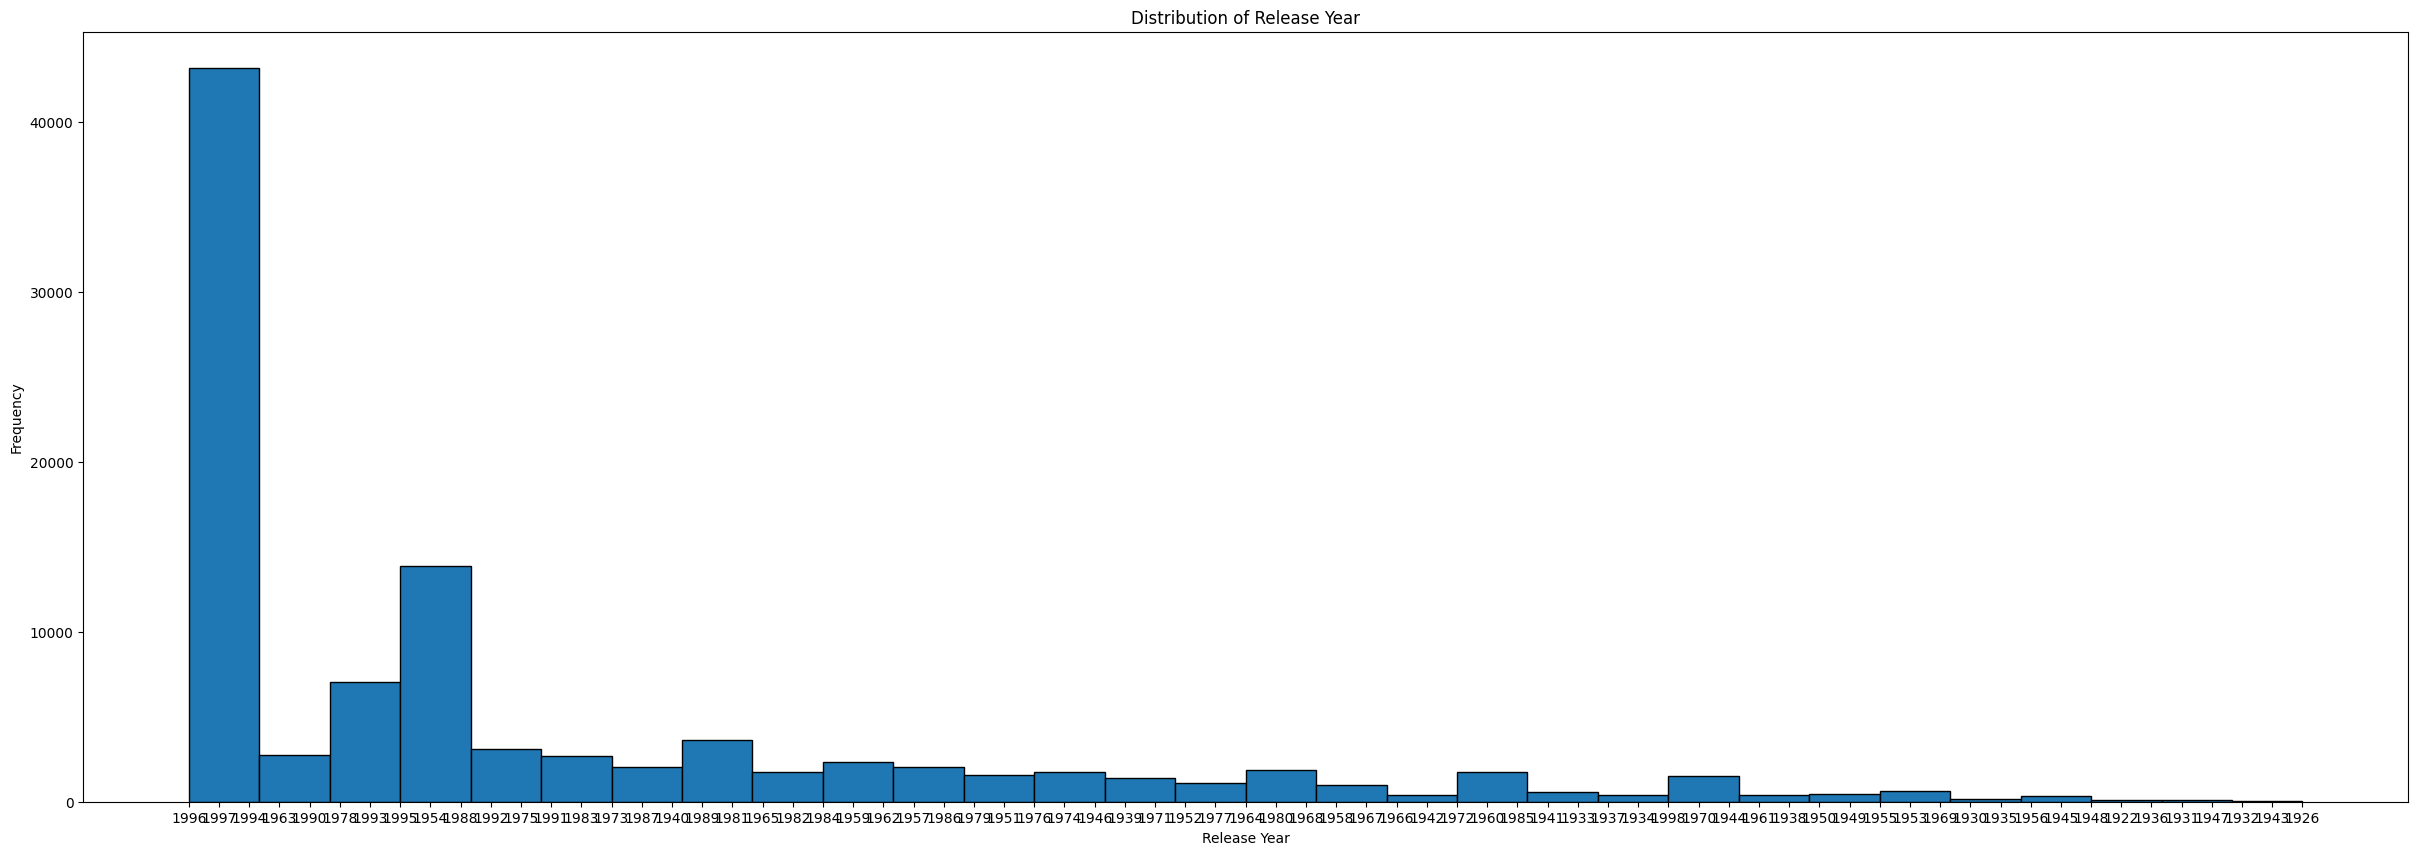

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30,10))
plt.hist(new_df['year'].dropna(), bins=30, edgecolor='black')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.title('Distribution of Release Year')
plt.show()


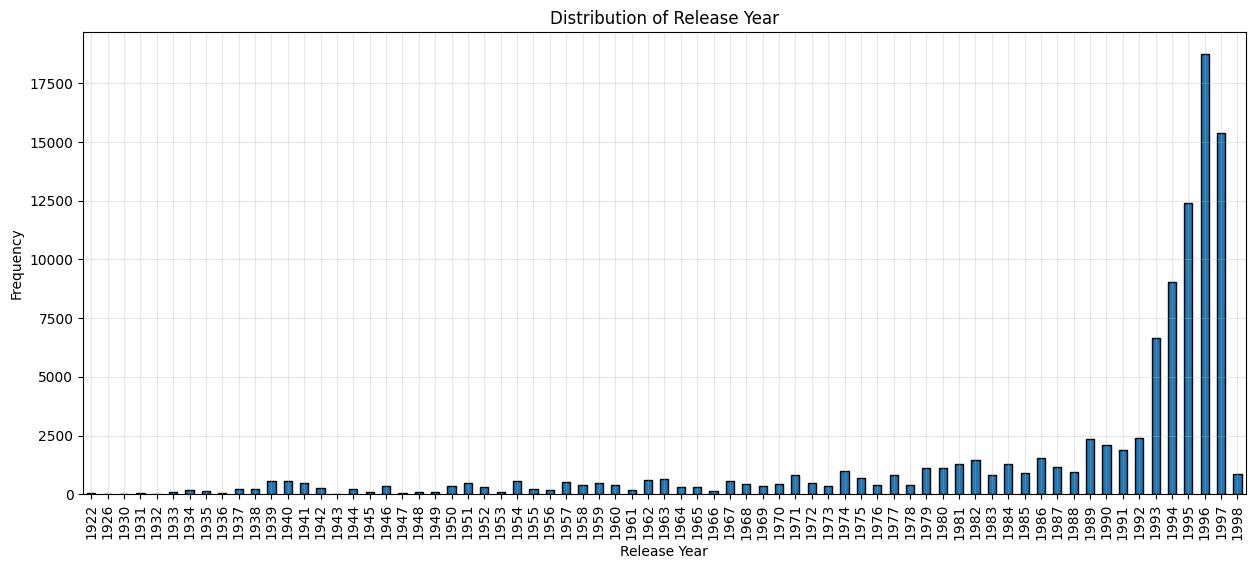

In [133]:
# تعداد فیلم‌ها برای هر سال
year_counts = new_df['year'].value_counts().sort_index()

plt.figure(figsize=(15, 6))
year_counts.plot(kind='bar', edgecolor='black')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.title('Distribution of Release Year')
plt.xticks(rotation=90)  # چرخش ۹۰ درجه برای خوانایی
plt.grid(True, alpha=0.3)
plt.show()

In [134]:
new_df['year'].min()

'1922'

In [135]:
new_df['year'].max()

'1998'

In [136]:

year_counts = new_df['year'].value_counts().sort_index()
year_counts

year
1922       54
1926        2
1930       18
1931       44
1932       12
        ...  
1994     9034
1995    12408
1996    18745
1997    15384
1998      851
Name: count, Length: 71, dtype: int64

# Test on the matrix

In [137]:
new_df

,user_id,movie_id,rating,user_idx,movie_title,year,clean_title
0,196,242,3,0,Kolya (1996),1996,Kolya
1,186,302,3,1,L.A. Confidential (1997),1997,L.A. Confidential
2,22,377,1,2,Heavyweights (1994),1994,Heavyweights
3,244,51,2,3,Legends of the Fall (1994),1994,Legends of the Fall
4,166,346,1,4,Jackie Brown (1997),1997,Jackie Brown
...,...,...,...,...,...,...,...
99995,880,476,3,875,"First Wives Club, The (1996)",1996,"First Wives Club, The"
99996,716,204,5,708,Back to the Future (1985),1985,Back to the Future
99997,276,1090,1,37,Sliver (1993),1993,Sliver
99998,13,225,2,58,101 Dalmatians (1996),1996,101 Dalmatians


In [138]:
rating_matrix

movie_idx,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
user_idx,,,,,,,,,,,,,,,,,,,,,
0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,1.0,NaN,NaN,NaN,3.0,NaN,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,NaN,NaN,4.0,NaN,4.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
939,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [139]:
rating_matrix.loc[3].dropna()

movie_idx
3       2.0
6       4.0
8       4.0
9       4.0
12      2.0
       ... 
1143    3.0
1171    4.0
1210    3.0
1245    5.0
1619    5.0
Name: 3, Length: 238, dtype: float64

In [140]:
rated_movies = rating_matrix.loc[3].dropna().index
rated_movies

Index([   3,    6,    8,    9,   12,   13,   22,   23,   24,   26,
       ...
       1089, 1092, 1100, 1119, 1138, 1143, 1171, 1210, 1245, 1619],
      dtype='int64', name='movie_idx', length=238)

In [141]:
all_movies = rating_matrix.columns

unrated_movies = all_movies.difference(rated_movies)

In [142]:
unrated_movies

Index([   0,    1,    2,    4,    5,    7,   10,   11,   14,   15,
       ...
       1672, 1673, 1674, 1675, 1676, 1677, 1678, 1679, 1680, 1681],
      dtype='int64', name='movie_idx', length=1444)

In [143]:
predictions = []

for movie_id in unrated_movies:
    pred_rating = np.dot(P[3], Q[movie_id])

    predictions.append({
        'movie_idx': movie_id,
        'predicted_rating': pred_rating
    })

In [144]:
pred_df = pd.DataFrame(predictions)

In [145]:
top_recommendations = pred_df.sort_values(
    'predicted_rating',
    ascending=False
)

print(top_recommendations.head(10))

      movie_idx  predicted_rating
247         359          4.815973
134         189          4.747030
205         297          4.687698
1018       1255          4.652025
349         496          4.632953
704         920          4.607003
22           36          4.603858
176         260          4.587621
731         950          4.557980
130         185          4.518695


### Clip between 1 to 5

In [146]:
predictions_clipped = []

for movie_id in unrated_movies:
    pred_rating = np.dot(P[3], Q[movie_id])
    pred_rating = np.clip(pred_rating, 1, 5)

    predictions_clipped.append({
        'movie_idx': movie_id,
        'predicted_rating': pred_rating
    })

In [147]:
pred = pd.DataFrame(predictions_clipped)

In [148]:
pred

,movie_idx,predicted_rating
0,0,3.629993
1,1,3.788006
2,2,1.603638
3,4,3.927585
4,5,4.308752
...,...,...
1439,1677,1.000000
1440,1678,1.000000
1441,1679,1.000000
1442,1680,1.064602


In [149]:
top_recommendations = pred.sort_values(
    'predicted_rating',
    ascending=False
)

print(top_recommendations.head(10))

      movie_idx  predicted_rating
247         359          4.815973
134         189          4.747030
205         297          4.687698
1018       1255          4.652025
349         496          4.632953
704         920          4.607003
22           36          4.603858
176         260          4.587621
731         950          4.557980
130         185          4.518695


### Add them to the matrix

In [150]:
top_recommendations[top_recommendations['movie_idx'] == 1]

,movie_idx,predicted_rating
1,1,3.788006


In [151]:
rating_matrix

movie_idx,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
user_idx,,,,,,,,,,,,,,,,,,,,,
0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,1.0,NaN,NaN,NaN,3.0,NaN,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,NaN,NaN,4.0,NaN,4.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
939,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [152]:

rating_matrix.loc[3, pred['movie_idx']] = pred['predicted_rating'].values

In [153]:
rating_matrix

movie_idx,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
user_idx,,,,,,,,,,,,,,,,,,,,,
0,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,1.000000,NaN,NaN,NaN,3.0,NaN,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.629993,3.788006,1.603638,2.0,3.927585,4.308752,4.0,3.409758,4.0,4.0,...,3.149777,1.0,1.099184,1.0,1.0,1.0,1.0,1.0,1.064602,1.0
4,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
939,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [154]:
rating_matrix.loc[3]

movie_idx
0       3.629993
1       3.788006
2       1.603638
3       2.000000
4       3.927585
          ...   
1677    1.000000
1678    1.000000
1679    1.000000
1680    1.064602
1681    1.000000
Name: 3, Length: 1682, dtype: float64

In [155]:
rating_matrix

movie_idx,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
user_idx,,,,,,,,,,,,,,,,,,,,,
0,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,1.000000,NaN,NaN,NaN,3.0,NaN,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.629993,3.788006,1.603638,2.0,3.927585,4.308752,4.0,3.409758,4.0,4.0,...,3.149777,1.0,1.099184,1.0,1.0,1.0,1.0,1.0,1.064602,1.0
4,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
939,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
